In [ ]:
# Polariton Disorder — Computation Notebook

# Runs the kernel pre-computation and Picard self-energy solve for one or more
# parameter sets.  Results are saved to `Results/` as `.npy` arrays with
# accompanying `_meta.json` sidecar files.

# **Workflow**
# 1. Define a base `Params` and any sweep axes in *Cell 2 – Parameters & sweep*.
# 2. Run *Cell 3 – Sweep helpers* to expand the parameter combinations.
# 3. Run *Cell 4 – Kernel mesh* to build and save `K(q,k)` integrand meshes.
# 4. Run *Cell 5 – Picard solve* to compute `Q(k, eta)` for all sweep points.
# 5. Open `Visualisations.ipynb` to plot saved results.


alpha_e = 149.0813648293963, alpha_h = 22.1875


In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from polaritons.parameters import Params

# ---------------------------------------------------------------------------
# Base parameter set  (modify here to change the physics)
# ---------------------------------------------------------------------------

base = Params(
    # Material (GaAs)
    E_bind       = 4.2e-3,          # eV  — exciton binding energy
    E_gap_bare   = 1.6,             # eV  — bare band gap
    m_e          = 3.81e-13,        # eV·s²/m²
    m_h          = 2.56e-12,        # eV·s²/m²
    m_rest       = 5.68e-12,        # eV·s²/m²

    # Polariton / cavity
    Omega        = 1.4e-2,          # eV  — Rabi splitting
    m_prime      = 10.0,            # dimensionless band-structure constant
    n_refr       = 3.0,             # cavity refractive index
    N_qw         = 1,               # number of quantum wells

    # Disorder
    D_0          = 2.26e-20,        # eV²·m²
    xi           = 20e-9,           # m  — correlation length

    # Thermodynamics
    T            = 20.0,            # K
    concentration = 0.3e12,         # m⁻²
    g_ex         = 12e-18,          # eV·m²
)

# ---------------------------------------------------------------------------
# Parameter sweep axes
#
# Each entry is  (param_name, list_of_values).
# All combinations are explored.  Use a single-element list to hold a param fixed.
# ---------------------------------------------------------------------------

SWEEP = {
    "xi"    : [10e-9, 20e-9, 40e-9],   # correlation length (m)
    "D_0"   : [2.26e-20],              # disorder strength — single value keeps it fixed
}

# eta grid — disorder amplitude sweep (always included)
eta_grid = np.round(np.linspace(0.0, 2.0, 21), 9)

print(f"Base params:\n  E_bind={base.E_bind*1e3:.1f} meV,  xi={base.xi*1e9:.0f} nm,  "
    f"T={base.T:.0f} K,  D_0={base.D_0:.2e} eV²m²")
print(f"Sweep axes: {list(SWEEP.keys())}")
print(f"eta_grid: {len(eta_grid)} points from {eta_grid[0]} to {eta_grid[-1]}")


In [ ]:
## Sweep helpers

Build all parameter combinations and convert each to natural units.


In [ ]:
import itertools
from dataclasses import replace

def build_sweep_params(base: Params, sweep: dict) -> list[Params]:
    """
    Return a list of Params objects, one for each combination of sweep values.

    Parameters
    ----------
    base   : base Params (SI units)
    sweep  : dict mapping field names to lists of values to sweep over

    Example
    -------
    sweep = {"xi": [10e-9, 20e-9], "T": [10.0, 20.0]}
    → 4 Params objects covering all (xi, T) combinations
    """
    keys   = list(sweep.keys())
    values = list(sweep.values())
    combos = list(itertools.product(*values))

    params_list = []
    for combo in combos:
        overrides = dict(zip(keys, combo))
        p = replace(base, **overrides)
        params_list.append(p)
    return params_list


sweep_params_si      = build_sweep_params(base, SWEEP)
sweep_params_natural = [p.to_natural() for p in sweep_params_si]

print(f"{len(sweep_params_si)} parameter set(s) in sweep:")
for i, p in enumerate(sweep_params_si):
    print(f"  [{i}]  xi={p.xi*1e9:.0f} nm  D_0={p.D_0:.2e}  T={p.T:.0f} K")


Completed coarse kernel evaluation on non-uniform segmented grid.
Coarse grid: N=2000  →  N_A=500, N_B=200, N_C=1100, N_D=200
Picard grid: N=10000  →  N_A=2500, N_B=1000, N_C=5500, N_D=1000
Boundaries (m⁻¹): 0 | 1.0e+08 | 2.0e+09 | 8.0e+09 | 1.2e+10
Coarse grid: N=2000  →  N_A=500, N_B=200, N_C=1100, N_D=200
Picard grid: N=10000  →  N_A=2500, N_B=1000, N_C=5500, N_D=1000
Boundaries (m⁻¹): 0 | 1.0e+08 | 2.0e+09 | 8.0e+09 | 1.2e+10


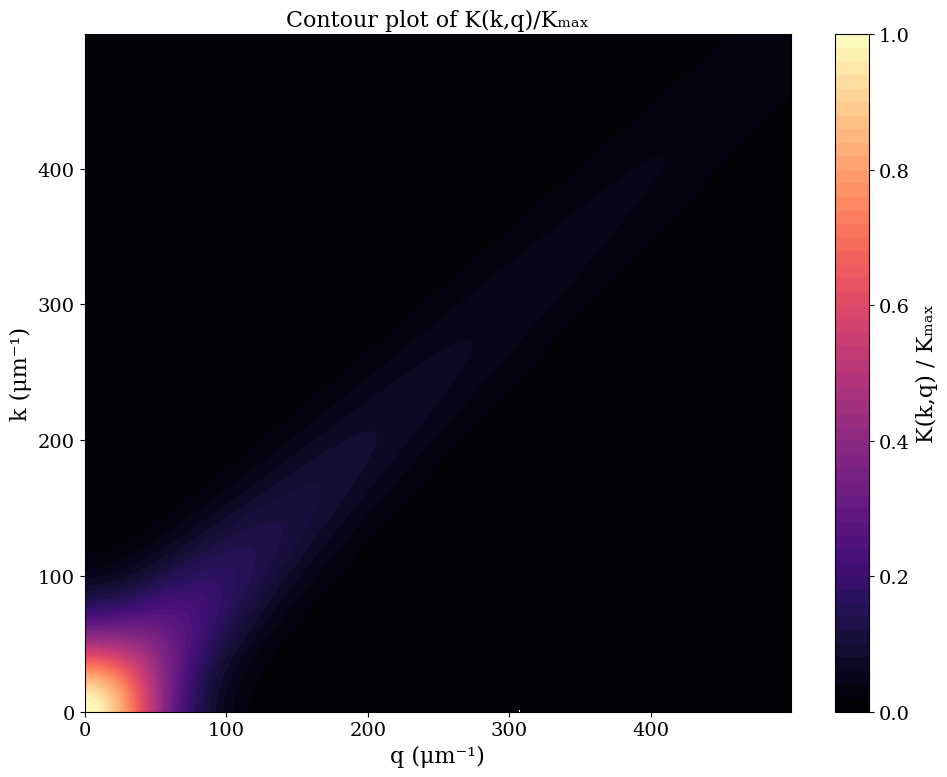

In [ ]:
## Kernel mesh pre-computation

For each parameter set in the sweep:
1. Build the 4-segment non-uniform momentum grid.
2. Evaluate `K(q, k)` on a coarse grid.
3. Interpolate onto the finer Picard grid.
4. Save the mesh + metadata to `Results/integrand_meshes/`.


In [ ]:
from scipy.interpolate import RectBivariateSpline
from polaritons.kernel import make_kernel_gaussian, make_kernel_nongaussian
from polaritons.grid   import build_segmented_grid, trapz_weights
from polaritons.io     import save_result, make_sweep_stem

# ---------------------------------------------------------------------------
# Grid configuration  (shared across all sweep points)
# ---------------------------------------------------------------------------

USE_GAUSSIAN = True   # set False to use white-noise (non-Gaussian) kernel

# Segment boundaries in SI (m^-1), converted to natural units per-sweep
Q_A_END_SI = 1e8    # IR / coarse boundary
Q_B_END_SI = 2e9    # coarse / resonance boundary
Q_C_END_SI = 8e9    # resonance / tail boundary
K_DOMAIN_MAX_SI = 1.2e10  # upper momentum limit

N_COARSE = 2_000    # coarse evaluation grid
N_PICARD = 10_000   # Picard quadrature grid

# Fraction of points per segment (same for coarse and Picard grids)
FRACS = dict(frac_A=0.25, frac_B=0.10, frac_C=0.55, frac_D=0.10, power_A=2.0)

# ---------------------------------------------------------------------------
# Loop over sweep parameter sets
# ---------------------------------------------------------------------------

kernel_stems = []   # collect stems for use in the Picard cell

for idx, (p_si, p_nat) in enumerate(zip(sweep_params_si, sweep_params_natural)):
    print(f"\n── Sweep set [{idx}]: xi={p_si.xi*1e9:.0f} nm, D_0={p_si.D_0:.2e} ──")

    # Convert grid boundaries to natural units
    L_u = p_si.a       # length unit (m)
    q_A = Q_A_END_SI   * L_u
    q_B = Q_B_END_SI   * L_u
    q_C = Q_C_END_SI   * L_u
    q_max = K_DOMAIN_MAX_SI * L_u

    # Build grids
    q_coarse, _ = build_segmented_grid(N_COARSE, q_A, q_B, q_C, q_max, **FRACS)
    q_picard, counts = build_segmented_grid(N_PICARD, q_A, q_B, q_C, q_max, **FRACS)

    print(f"  Picard grid: N={len(q_picard)}, "
          f"N_A={counts['N_A']}, N_B={counts['N_B']}, "
          f"N_C={counts['N_C']}, N_D={counts['N_D']}")

    # Evaluate K on coarse grid (vectorized, blocked internally)
    K_fn = (make_kernel_gaussian if USE_GAUSSIAN else make_kernel_nongaussian)(p_nat, n_gauss=96)
    print(f"  Computing kernel mesh ({N_COARSE}×{N_COARSE}) ...")
    mesh_coarse = K_fn(q_coarse, q_coarse)

    # Interpolate to Picard grid
    interp = RectBivariateSpline(q_coarse, q_coarse, mesh_coarse)
    mesh_picard = interp(q_picard, q_picard)

    # Save
    extra_meta = {
        "kernel_type"    : "gaussian" if USE_GAUSSIAN else "nongaussian",
        "N_coarse"       : N_COARSE,
        "N_picard"       : N_PICARD,
        "q_picard"       : q_picard.tolist(),   # grid stored in metadata for full reproducibility
        "grid_fracs"     : FRACS,
        "q_boundaries_si": [Q_A_END_SI, Q_B_END_SI, Q_C_END_SI, K_DOMAIN_MAX_SI],
        "sweep_index"    : idx,
    }
    stem = make_sweep_stem("K", p_si, extra={"kernel": "gaussian" if USE_GAUSSIAN else "ng"})
    save_result(mesh_picard, "Results/integrand_meshes", stem, p_si, extra_meta)
    kernel_stems.append(stem)

print(f"\nAll kernels saved.  Stems: {kernel_stems}")


In [ ]:
## Picard self-energy solve

For each saved kernel mesh, run the Picard iteration over all `eta` values
and save `Q_results` (shape `[len(eta_grid), N_picard]`, complex128).

The `q_picard` grid and all parameter metadata are embedded in the sidecar JSON
so that `Visualisations.ipynb` can reconstruct the `DispersionModel` without
any other inputs.


Running Picard iteration for eta = 0.0, index = 0/21
Iteration 1, diff = 140.00714267494052
Iteration 1, diff = 140.00714267494052
Running Picard iteration for eta = 0.1, index = 1/21
Running Picard iteration for eta = 0.1, index = 1/21
Iteration 1, diff = 109.0985108428903
Iteration 1, diff = 109.0985108428903
Running Picard iteration for eta = 0.2, index = 2/21
Running Picard iteration for eta = 0.2, index = 2/21
Iteration 1, diff = 116.36615602469587
Iteration 1, diff = 116.36615602469587
Running Picard iteration for eta = 0.3, index = 3/21
Running Picard iteration for eta = 0.3, index = 3/21
Iteration 1, diff = 102.59600508446758
Iteration 1, diff = 102.59600508446758
Running Picard iteration for eta = 0.4, index = 4/21
Running Picard iteration for eta = 0.4, index = 4/21
Iteration 1, diff = 94.39702045068775
Iteration 1, diff = 94.39702045068775
Running Picard iteration for eta = 0.5, index = 5/21
Running Picard iteration for eta = 0.5, index = 5/21
Iteration 1, diff = 88.71791230

In [ ]:
## Picard self-energy solve

For each saved kernel mesh, run the Picard iteration over all `eta` values
and save `Q_results` (shape `[len(eta_grid), N_picard]`, complex128).

The `q_picard` grid and all parameter metadata are embedded in the sidecar JSON
so that `Visualisations.ipynb` can reconstruct the `DispersionModel` without
any other inputs.


In [ ]:
from polaritons.solver import picard_iteration
from polaritons.kernel import make_propagator
from polaritons.grid   import build_segmented_grid, trapz_weights
from polaritons.io     import load_result, save_result, make_sweep_stem

# Picard iteration settings
PICARD_TOL      = 1e-6
PICARD_MAX_ITER = 5000
PICARD_W        = 0.99    # under-relaxation factor

for idx, (p_si, p_nat, k_stem) in enumerate(
    zip(sweep_params_si, sweep_params_natural, kernel_stems)
):
    print(f"\n── Sweep set [{idx}]: xi={p_si.xi*1e9:.0f} nm, D_0={p_si.D_0:.2e} ──")

    # Load the corresponding kernel mesh + metadata
    K_mesh, k_meta = load_result("Results/integrand_meshes", k_stem)
    q_picard       = np.array(k_meta["q_picard"])
    N_pic          = len(q_picard)
    weights        = trapz_weights(q_picard)

    # Build the propagator for this parameter set
    F_fn = make_propagator(p_nat)

    # Warm-start from a constant complex initial guess
    Q_init = (1 + 1j) * np.ones(N_pic, dtype=complex)

    Q_results = np.zeros((len(eta_grid), N_pic), dtype=complex)

    for ei, eta in enumerate(eta_grid):
        print(f"  η={eta:.3f}  ({ei+1}/{len(eta_grid)})")
        Q_conv, _ = picard_iteration(
            Q_init, q_picard, K_mesh, weights, F_fn,
            eta=eta, tol=PICARD_TOL, max_iter=PICARD_MAX_ITER,
            w=PICARD_W, verbose=False,
        )
        Q_results[ei] = Q_conv
        Q_init        = Q_conv.copy()   # warm-start next eta

    # Save Q results
    extra_q = {
        "eta_grid"       : eta_grid.tolist(),
        "q_picard"       : q_picard.tolist(),
        "kernel_stem"    : k_stem,
        "picard_tol"     : PICARD_TOL,
        "picard_max_iter": PICARD_MAX_ITER,
        "picard_w"       : PICARD_W,
        "sweep_index"    : idx,
    }
    q_stem = make_sweep_stem("Q", p_si, extra={"kernel": k_stem})
    save_result(Q_results, "Results/Q_results", q_stem, p_si, extra_q)

print("\nAll Picard solves complete.")
